#**Regression Course**

---

In this course, you will learn how to apply ***the supervised learning workflow (explained in Section 4 of the lecture) to regression problems***. We will use **"linear regression" model** throughout the exercises and look at each step of the workflow: ***understanding the data, processing data, model building, and model evaluation***.The goal is to practice the knowledge required for each step depending on the level.

# Level 2 (★★☆☆)

---

In Level 2, we will first remove outliers from the data. Then, we will train a model using the preprocessed data and make predictions.

The question is, how can we determine which values are outliers?  
We will explore two different methods for identifying outliers — one in Level 2 and another in Level 3.


## 2.1. Preprocessing Data


In this Level 2 exercise, we will continue to use the `Car_Price_Data.csv` from Level 1.  
As a quick review of Level 1, please download the file from the link below, upload it to the designated location, and use the code provided to load it into a DataFrame.  
Then, let's begin by removing rows that contain missing values.

[Car_Price_Data.csv](https://drive.google.com/file/d/1YVQgy_jAwSVH5YEMdWlrTzkXEf7no860/view?usp=drive_link)


In [ ]:
import pandas as pd

df = pd.read_csv('Car_Price_Data.csv')
df = df.dropna()

Outliers are data points that take on extreme values compared to the rest of the dataset. They can occur due to various reasons, such as measurement errors. If you perform data analysis with outliers included, they may have a significant impact on the results. For this reason, outliers are sometimes removed.

There are several methods to identify outliers, but in this notebook, we will focus on identifying them using **scatter plots** or **box plots**.


**【Removing Outliers】**

*  Based on a box plot (Level 2 ★★☆☆)
*  Based on scatter plot (Level 3 ★★★☆)


In this lesson, we will use a **box plot** to define outliers quantitatively.  
A commonly used rule is to treat data as outliers if they fall below "Q1 - 1.5 × IQR" or above "Q3 + 1.5 × IQR".  

Here, **IQR** stands for the *interquartile range*, which is calculated as:  
**(third quartile) − (first quartile)**.


To create a box plot, we will import the `pyplot` module from the **matplotlib** library and also use the **seaborn** library.


Let’s try creating a box plot for the `engine-size` column. First, use the `figure()` function to specify the width and height of the plot via arguments.

Then, use the `boxplot()` function to specify the data to be plotted — in this case, the `engine-size` column. Use the `ylabel()` function to set the label for the y-axis, and finally, use the `show()` function to display the plot. Unless otherwise specified, outliers will be automatically marked with circles (◯) on the box plot based on the criteria mentioned earlier.


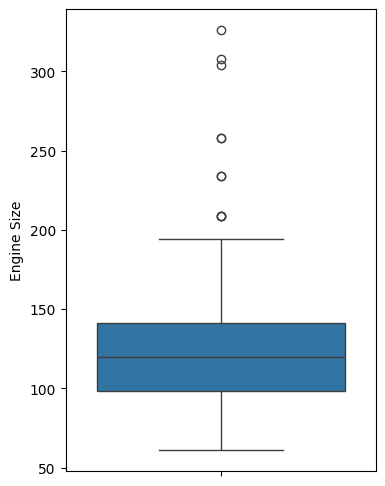

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 6))
sns.boxplot(y=df['engine-size'])
plt.ylabel('Engine Size')
plt.show()

**Six outliers are displayed** on the plot, according to the criteria.


Next, we will remove the outliers based on the criteria we just confirmed.  
Any data points that fall outside the specified upper and lower bounds will be considered outliers. We will then return a new DataFrame with those outliers removed.


To begin, we will extract the column from the DataFrame that we want to remove outliers of. Then, we will use the `describe()` method to display various **summary statistics** for that column.


In [ ]:
columns = ['engine-size', 'curb-weight', 'city-mpg']
desc = df[columns].describe()
desc

We will use the `loc[]` attribute to extract the first quartile (Q1) and the third quartile (Q3) rows from the statistics output.  The `loc[]` attribute allows you to access specific rows or columns by specifying their **labels** inside square brackets `[ ]`, similar to how you would use indexing in NumPy.


In [ ]:
Q1 = desc.loc['25%']
Q3 = desc.loc['75%']
Q1

Next, we calculate the interquartile range (IQR) by subtracting Q1 from Q3.  
We then define the range of non-outlier values as follows:  
- The lower bound is Q1 minus 1.5 times the IQR  
- The upper bound is Q3 plus 1.5 times the IQR


In [ ]:
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound

By specifying the column name here, you can output the **lower bound** corresponding to that column.


In [ ]:
lower_bound['engine-size']

First, let's consider keeping only the values in the `engine-size` column that fall between the lower and upper bounds.
In such cases, you can set conditions using **comparison operators**. For example, to keep only the data where the values in the `engine-size` column are greater than or equal to 100, you can use a comparison operator like this:


In [ ]:
is_over_100 = df['engine-size'] >= 100
is_over_100

The variable `is_over_100` contains **Boolean values (True or False)** indicating whether each row meets the condition that the `engine-size` column is greater than or equal to 100.  
If the condition is met, the value is `True`; otherwise, it is `False`.

To filter a DataFrame using this kind of Boolean information, you can add square brackets `[ ]` after the variable name that holds the DataFrame, and place the Boolean values inside.  
This will return only the rows where the value is `True`.

Let’s filter the DataFrame to keep only the rows where the `engine-size` column is greater than or equal to 100 (i.e., the rows where `is_over_100` is `True`).


In [ ]:
df_over_100 = df[is_over_100]

With this, we have successfully kept only the data we wanted.

To apply **multiple conditions**, you can use the following symbols:


| Variable | Definiton |
|------|------|
| ＆ | and |
| ｜ | or |
| ～ | not |

In this case, we want to keep the data that meets both conditions: values greater than or equal to the lower bound and less than or equal to the upper bound. To do this, we connect the two conditions using the `&` operator.


In [ ]:
df2 = df[(df['engine-size'] >= lower_bound['engine-size']) & (df['engine-size'] <= upper_bound['engine-size'])]

However, in this case, we want to apply the same outlier removal process not only to the `engine-size` column, but also to `curb-weight` and `city-mpg`. When you need to repeat the same process for multiple columns, you can use a `for` loop.


Below is a simple example combining a `for` loop with a **list**. You can see that the `for` loop goes through each element in the list and displays them one by one.


In [ ]:
menu = ['salad', 'soup', 'steak', 'cake']
for food in menu:
    print(food)

Let’s return to the automobile dataset.  
First, we will store the column names we want to process in a list, since we’ll be repeating the same process for each of them.


In [ ]:
columns = ['engine-size', 'curb-weight', 'city-mpg']

Now, referring to the code we wrote earlier for the `engine-size` column, we’ll incorporate that logic into a `for` loop. The result will look like the following:


In [ ]:
for column in columns:
    df = df[(df[column] >= lower_bound[column]) & (df[column] <= upper_bound[column])]

# The line below is the same one we used earlier for the engine-size column:
# df2 = df[(df['engine-size'] >= lower_bound['engine-size']) & (df['engine-size'] <= upper_bound['engine-size'])]

When you run the `for` loop above, it first processes the `engine-size` column,  extracting only the data that falls between the lower and upper bounds.  
This effectively removes the outliers from the `engine-size` column.

Then, the same process is repeated for the `curb-weight` and `city-mpg` columns,  which are also included in the `columns` list.  
By removing outliers from each column individually, we end up with a DataFrame where outliers have been removed from all three columns.

In this example, we only handled three columns, but the more columns you need to process, the more useful and powerful a `for` loop becomes.


As before, we will split the data into explanatory variables and target variable.


In [ ]:
X = df.drop('price', axis=1)
y = df['price']

## 2.2. Model Building and Evaluation


The training and evaluation methods are the same as before.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=0)

scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print('R² score for each split:', scores)
print('Average R² score from cross-validation:', scores.mean())


As a result of removing outliers using a box plot, the model's accuracy decreased compared to Level 1, where outliers were not removed.　This shows that removing outliers does not always lead to improved accuracy.


## 2.3. Practice Problems

**Q2-1.**
Create the DataFrame shown in Table 1 below, and remove the rows where column A is greater than or equal to 10.

**Table 1**

| A  | B  |
|----|----|
| 5  | 8  |
| 12 | 9  |
| 7  | 6  |


**Q2-2.** Download the file `Regression_Lv2_Practice.csv` from the link below and upload it.  
Then, remove outliers from the `engine-size` column using the following rule:  
Any data below "Q1 - 2 × IQR" or above "Q3 + 2 × IQR" should be considered an outlier.

[Regression_Lv2_Practice.csv](https://drive.google.com/file/d/17DzMfZnmXs8LiQ-IiG5KvM_wX2-DrktP/view?usp=drive_link)
